# Class 5 - Geospatial Data (netCDF & xarray)

Recommended documentation: [Geospatial course from UGhent](https://github.com/plovercode/DS-python-geospatial/tree/main/notebooks)


Today we move from **time-series tabular data** (pandas, Class 4) to **multi-dimensional gridded data**.

Goals:
- understand what a netCDF file is and how to read it with  **xarray** ,
- select, slice, reduce, filter, `groupby`, and `resample` gridded temperature data,
- apply simple raster operations: value masking and selecting a geographic region with **regionmask**.

> **Scope of this course:** we only work with **raster / netCDF** data. We will **not** cover shapefiles or vector GIS (GeoPandas, etc.).

## 1. From pandas to xarray

In Class 4, each row was one time step and each column was one variable (temperature, humidity, …). That works well for a **point station**.

Gridded climate data has more axes at once, for example:

- **time** (hourly steps in January 2024),
- **latitude**,
- **longitude**,
- and one or more **data variables** (here: predicted temperature).

![xarray Dataset: data variables, coordinates, and attributes](img/xarray-dataset.png)

*Figure: an `xarray.Dataset` can hold several data variables that share coordinates (e.g. lon, lat, time), plus metadata in attributes. (Source: [xarray documentation](https://docs.xarray.dev/).)*


## 2. The data

We use Future Forests **predicted 2 m air temperature** (`pred_temperature_C`) for January 2024 on a ~100 m grid over the project area provided by Christopher Jung.

The raw file is stored in projected coordinates (EPSG:25832, ETRS89 / UTM zone 32N). For class, we use a **preprocessed lon/lat (WGS84)** version:

```text
../processed_data/pred_temperature_C_2024_01_wgs84.nc
```

In [5]:
# Running this cell can take a few minutes
import matplotlib.pyplot as plt
import xarray as xr
import regionmask

## 3. Opening a netCDF with xarray

`xr.open_dataset` reads the file and returns a **Dataset**: a dictionary-like container of labelled arrays (DataArrays) that share dimensions.


In [6]:
DataPath = "../processed_data/pred_temperature_C_2024_01_wgs84.nc"
# Lazy open: do not load the full ~3 GB grid into memory at once
TempDs = xr.open_dataset(DataPath, chunks="auto")
TempDs

<xarray.Dataset> Size: 11GB
Dimensions:             (time: 744, lat: 2132, lon: 1701)
Coordinates:
  * time                (time) datetime64[ns] 6kB 2024-01-01 ... 2024-01-31T2...
  * lat                 (lat) float64 17kB 49.65 49.65 49.65 ... 47.48 47.48
  * lon                 (lon) float64 14kB 7.311 7.312 7.313 ... 9.042 9.043
Data variables:
    pred_temperature_C  (time, lat, lon) float32 11GB dask.array<chunksize=(166, 474, 378), meta=np.ndarray>
    crs                 int64 8B ...
Attributes: (12/13)
    Conventions:            CF-1.8
    title:                  Predicted temperature on 100 m grid (reprojected ...
    source_file:            ["D:\\ERA5\\Future_Forests_Area\\d2m_C\\ERA5_2024...
    model_features:         ["Albedo_Albedo", "Albedo_Multiscale_Features_Alb...
    baseline_feature:       t2m_C
    baseline_scale_factor:  0.1
    ...                     ...
    institution:            Future Forests
    references:             LightGBM model application
    comment:                Prediction was calculated only for cells where th...
    featureType:            grid
    variable:               pred_temperature_C
    history:                Created on 2026-07-30T11:34:52.391813; Reprojecte...

On the table above we can observe:
1. There are 3 dimensions which are the 3 coordinates; `time` of size 744 (why?), `lat` of size 2132 and `lon` of size 1701.
2. There are two data variables, but only one is usuable (`crs` is for metadata): `pred_temperature_C` of shape `(time, lat, lon)`

Let's select the variable that interests us (there is only one variable in this file but there could be multiple):

In [16]:
Temp = TempDs["pred_temperature_C"]
print(Temp.dims)

('time', 'lat', 'lon')


`Temp` is a **`DataArray`**, an array of one variable (unlike the **`Dataset`**, which can hold several variables at once) with its own **dimension names** (`time`, `lat`, `lon`), **coordinate arrays** (`Temp.time`, `Temp.lat`, `Temp.lon`) and many other "**methods**" like `.dims`.

## 4. Selecting and slicing data

Similarly to `pandas`, there are two ways to select and slice data with `xarray`:

- **`.isel(...)`** select by **integer position** (like NumPy indexing)
- **`.sel(...)`** select by **coordinate label** (like pandas `.loc`)

In [ ]:
# Position-based: first time step
FirstMap = Temp.isel(time=0)

('lat', 'lon')


Quick map of the first time step with matplotlib. For a **2D grid** (lon × lat), use `plt.pcolormesh` to colour each cell

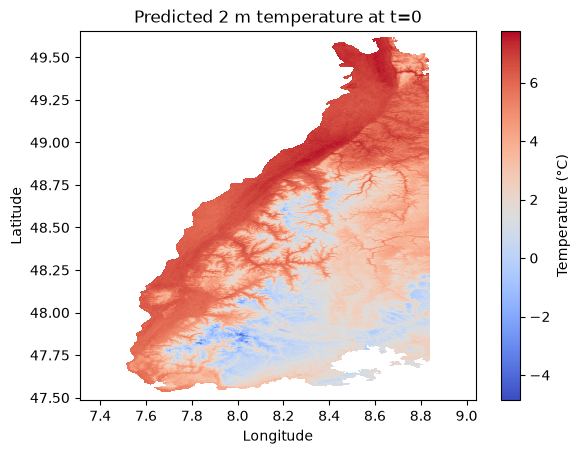

In [18]:
plt.pcolormesh(FirstMap.lon, FirstMap.lat, FirstMap, cmap="coolwarm", shading="auto")
# cmap = colormap (colour scale for the data values)
# shading = how the rectangular grid cells are rendered ("auto" infers it from lon/lat/data shapes)
# Always check the docs of each function you are using!
plt.colorbar(label="Temperature (°C)")
plt.title("Predicted 2 m temperature at t=0")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [19]:
# Label-based: temperature near Hartheim station (~7.60°E, 47.93°N)
HartheimLon, HartheimLat = 7.60, 47.93
HartheimSeries = Temp.sel(lon=HartheimLon, lat=HartheimLat, method="nearest") # Nearest is used here for inexact matches

Try to make a figure (which one will suit the most?) of `HartheimSeries`

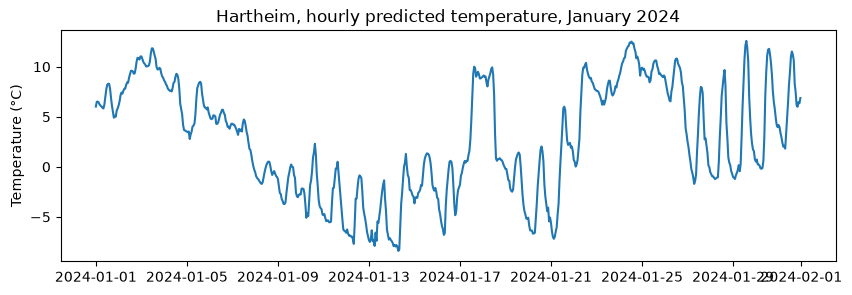

In [ ]:
# Solution
plt.plot(HartheimSeries.time, HartheimSeries)
plt.ylabel("Temperature (°C)")
plt.title("Hartheim, hourly predicted temperature, January 2024")
plt.show()

Spatial and temporal **slices** use `slice`


Frozen({'time': 744, 'lat': 2132, 'lon': 1701})
Frozen({'time': 744, 'lat': 392, 'lon': 589})


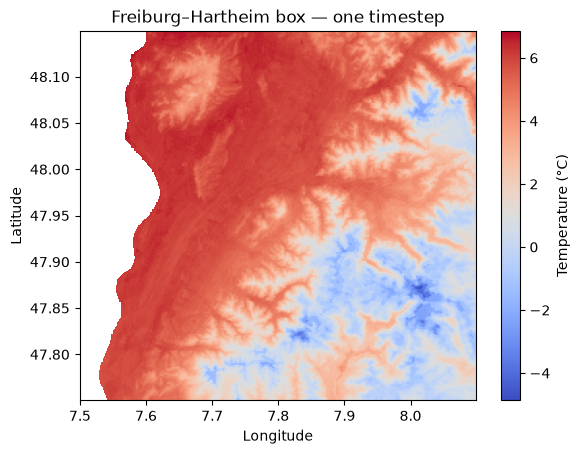

In [23]:
# Small box around Freiburg / Hartheim
print(Temp.sizes)
FreiburgBox = Temp.sel(
    lon=slice(7.5, 8.1),
    lat=slice(48.15, 47.75),  # high → low if lat decreases with index
)
print(FreiburgBox.sizes)

BoxMap = FreiburgBox.isel(time=0)

plt.pcolormesh(BoxMap.lon, BoxMap.lat, BoxMap, cmap="coolwarm", shading="auto")
plt.colorbar(label="Temperature (°C)")
plt.title("Freiburg–Hartheim box — one timestep")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

> **Note:** for latitude, values decrease north to south, this is not always the case.


## 5. Reduction

Let's say you want a map of average January temperature. You have hourly values at every grid cell, so you need to collapse the time dimension and keep the spatial ones.

Reductions such as `.mean()`, `.min()`, `.max()` can run along one or more named dimensions. It is the same idea as pandas aggregations, but you name the axis explicitly.


In [24]:
JanMeanMap = Temp.mean(dim="time")
print(JanMeanMap.dims)

('lat', 'lon')


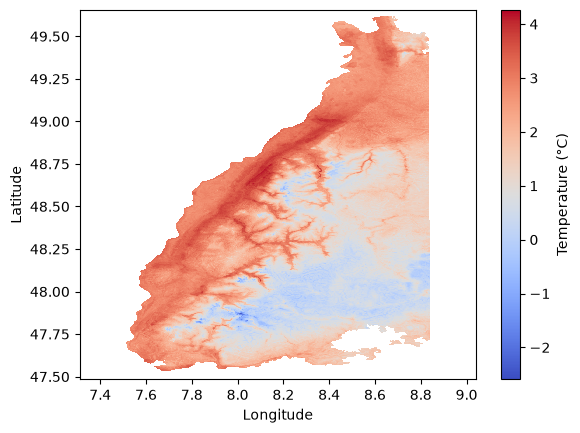

In [25]:
plt.pcolormesh(JanMeanMap.lon, JanMeanMap.lat, JanMeanMap, cmap="coolwarm", shading="auto")
plt.colorbar(label="Temperature (°C)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

Now ask how the region as a whole evolved during January. This time you collapse lat and lon and keep time, which leaves you with a single time series instead of a map.

In [ ]:
# Spatial mean over the Freiburg box → one value per time
BoxSpatialMean = FreiburgBox.mean(dim=("lat", "lon"))
print(BoxSpatialMean.dims)

('time',)


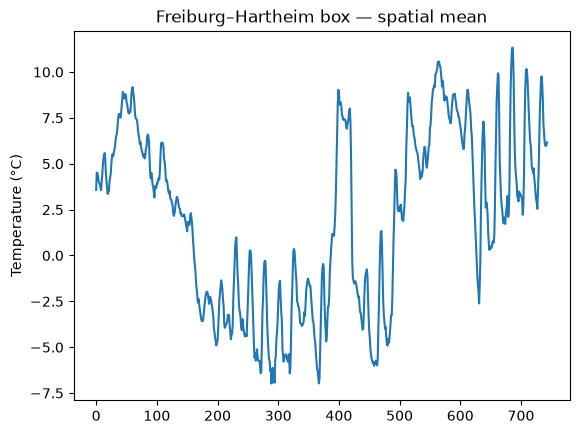

In [28]:
plt.plot(BoxSpatialMean)
plt.ylabel("Temperature (°C)")
plt.title("Freiburg–Hartheim box — spatial mean")
plt.show()

## Exercise A

Similarly to what we have done above, try to reduce the right dimension to make a zonal mean (or latitudinal) plot with `FreiburgBox`

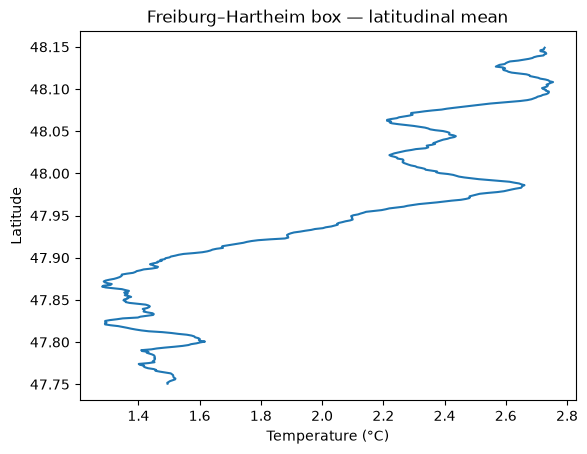

In [32]:
# Solution
BoxLatitudinalMean = FreiburgBox.mean(dim=("lon", "time"))
print(BoxLatitudinalMean.dims)

plt.plot(BoxLatitudinalMean.lat, BoxLatitudinalMean)
plt.xlabel("Latitude")
plt.ylabel("Temperature (°C)")
plt.title("Freiburg–Hartheim box — latitudinal mean")
plt.show()

## 6. Filtering / masking with `.where`

In **Class 3b**, you filtered NumPy arrays with a Boolean mask, e.g. `TempC[TempC > 21.0]`. That keeps only the matching values and **shrinks** the array.

When you need the **same shape** as the input, for example to plot a map where rejected cells are blank, you used `np.where(condition, value_if_true, np.nan)`.

xarray's `.where(condition)` does the same thing on a `DataArray`: it keeps values where the condition is `True` and sets the rest to `NaN` (grid shape unchanged — useful for maps).


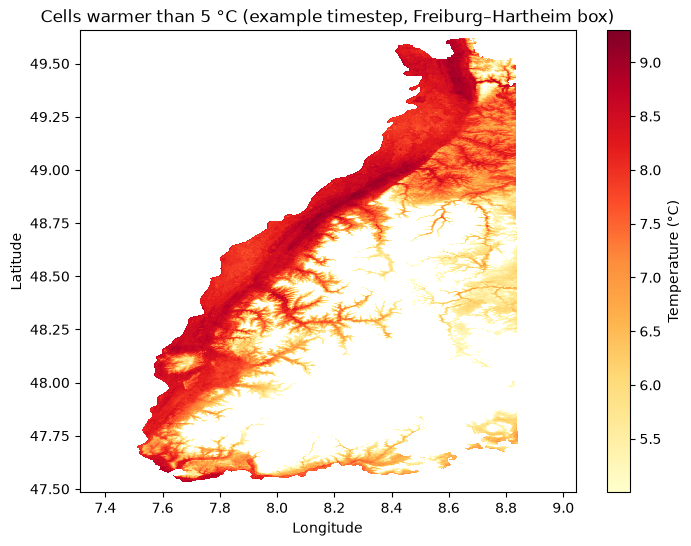

In [ ]:
WarmCells = Temp.where(Temp > 5)
WarmMap = WarmCells.isel(time=12)

plt.pcolormesh(WarmMap.lon, WarmMap.lat, WarmMap, cmap="YlOrRd", shading="auto")
plt.colorbar(label="Temperature (°C)")
plt.title("Cells warmer than 5 °C (example timestep, Freiburg–Hartheim box)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

## 7. Changing time resolution (`resample`)

In **Class 4**, you used `.resample('D').mean()` on the Hartheim station table to go from hourly to daily values. `xarray` does the same on gridded data: group timestamps into coarser bins, then aggregate, e.g. **`resample(time="1D")`:** calendar-day bins (then `.mean()`, `.sum()`, …)

The frequency strings differ slightly from pandas (`"1D"` vs `"D"`), but the idea is unchanged: **change the time resolution, then reduce**.


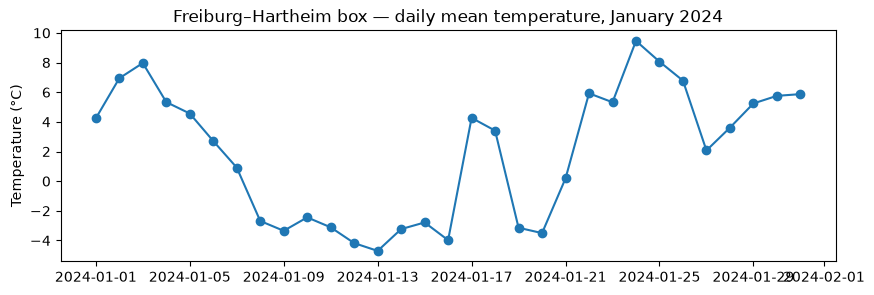

In [ ]:
# Daily means: spatial mean over the box, then change time resolution
BoxSeries = FreiburgBox.mean(dim=("lat", "lon"))
Daily = BoxSeries.resample(time="1D").mean()

plt.plot(Daily.time, Daily, marker="o")
plt.ylabel("Temperature (°C)")
plt.title("Freiburg–Hartheim box — daily mean temperature, January 2024")
plt.show()

## Exercise C

You want a January overview map and the coldest day in a Freiburg analysis box.

Tasks:
1. Select the box `lon=7.5–8.1`, `lat=48.15→47.75` (north→south order matches this file).
2. Compute the **time-mean** map for that box and plot it.
3. For the same box, compute the spatial mean at each time, find the **coldest** timestep, and print its timestamp and temperature.


In [ ]:
# Solution
Box = Temp.sel(lon=slice(7.5, 8.1), lat=slice(48.15, 47.75))
JanMean = Box.mean(dim="time").compute()

plt.pcolormesh(JanMean.lon, JanMean.lat, JanMean, cmap="coolwarm", shading="auto")
plt.colorbar(label="Temperature (°C)")
plt.title("January mean predicted temperature (Freiburg–Hartheim box)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

BoxMeanTs = Box.mean(dim=("lat", "lon")).compute()
ColdIdx = BoxMeanTs.argmin(dim="time")
ColdTime = BoxMeanTs.time.isel(time=ColdIdx)
ColdValue = BoxMeanTs.isel(time=ColdIdx)
print("Coldest time:", str(ColdTime.values)[:19])
print(f"Coldest box-mean temperature: {float(ColdValue):.2f} °C")


## Exercise D

Forest microclimate often shows a clear day–night contrast. Using the **Hartheim** point series from Exercise B:

Tasks:
1. Build the **diurnal cycle** with `groupby("time.hour").mean()` and plot it.
2. Resample the same series to **daily** means (`resample(time="1D").mean()`) and plot it.


In [ ]:
# Your code here


In [ ]:
# Solution
HartheimTs = Temp.sel(lon=7.60, lat=47.93, method="nearest")

HartheimDiurnal = HartheimTs.groupby("time.hour").mean()
plt.plot(HartheimDiurnal.hour, HartheimDiurnal, marker="o")
plt.xlabel("Hour of day (UTC)")
plt.ylabel("Temperature (°C)")
plt.title("Hartheim diurnal cycle — January 2024")
plt.show()

HartheimDaily = HartheimTs.resample(time="1D").mean()
plt.plot(HartheimDaily.time, HartheimDaily, marker="o")
plt.ylabel("Temperature (°C)")
plt.title("Hartheim daily mean temperature — January 2024")
plt.show()


## Exercise E

On a frosty morning, you want to see where the predicted temperature stays below freezing near Freiburg.

Tasks:
1. Select the Freiburg–Hartheim box (`lon=7.5–8.1`, `lat=48.15→47.75`), then the map for `2024-01-20T06:00` (nearest).
2. Mask so that **only cells < 0 °C** remain (others `NaN`).
3. Plot the masked map.


In [ ]:
# Solution
FrostMorning = Temp.sel(lon=slice(7.5, 8.1), lat=slice(48.15, 47.75)).sel(
    time="2024-01-20T06:00", method="nearest"
)
BelowZero = FrostMorning.where(FrostMorning < 0)

plt.pcolormesh(BelowZero.lon, BelowZero.lat, BelowZero, cmap="Blues_r", shading="auto")
plt.colorbar(label="Temperature (°C)")
plt.title("20 Jan ~06:00 — cells below 0 °C (Freiburg–Hartheim box)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


## Exercise F

Define a region covering the **Hartheim–Freiburg** corridor and summarise January inside it.

Tasks:
1. Create a `regionmask.Regions` polygon roughly covering lon `7.55–7.95`, lat `47.85–48.05`.
2. Build a mask on `Temp.lon` / `Temp.lat`.
3. Compute the **daily mean** temperature inside that region for January and plot it.


In [ ]:
# Solution
HartheimFreiburgVerts = [
    [7.55, 47.85],
    [7.95, 47.85],
    [7.95, 48.05],
    [7.55, 48.05],
    [7.55, 47.85],
]
HfRegions = regionmask.Regions(
    [HartheimFreiburgVerts],
    names=["Hartheim–Freiburg"],
    abbrevs=["HF"],
    name="Hartheim–Freiburg corridor",
)
HfTemp = Temp.sel(lon=slice(7.4, 8.1), lat=slice(48.15, 47.75))
HfMask = HfRegions.mask(HfTemp.lon, HfTemp.lat)

HfDaily = (
    HfTemp.where(HfMask == 0)
    .mean(dim=("lat", "lon"))
    .resample(time="1D")
    .mean()
    .compute()
)

plt.plot(HfDaily.time, HfDaily, marker="o")
plt.ylabel("Temperature (°C)")
plt.title("Hartheim–Freiburg region — daily mean temperature, January 2024")
plt.show()
